#  Exploratory Data Analysis: German Credit Risk Dataset

**Project Title:** Credit Score Prediction and Analysis using Logistic Regression

**Dataset:** Statlog (German Credit Data), UCI Machine Learning Repository

**Source:** Professor Dr. Hans Hofmann, Institut f&uuml;r Statistik und &Ouml;konometrie, Universit&auml;t Hamburg

---

## 1. Project Objective

The objective of this project is to analyze and model the creditworthiness of loan applicants using statistical and machine learning techniques, with **Logistic Regression** as the primary classification model. Logistic Regression is chosen deliberately because it rests on well-established statistical foundations &mdash; maximum likelihood estimation, odds ratios, the logit link function, and hypothesis testing on coefficients &mdash; which makes it well suited to a project grounded in fundamental statistical concepts rather than a purely black-box machine learning approach.

This notebook focuses exclusively on **Exploratory Data Analysis (EDA)**. The goals of this stage are to:

1. Understand the structure, quality, and distribution of the dataset.
2. Examine the target variable (credit risk) and assess class balance.
3. Study each predictor individually (univariate analysis) and in relation to the target (bivariate analysis).
4. Identify relationships, correlations, and potential multicollinearity among predictors.
5. Apply formal statistical tests to determine which features are significantly associated with credit risk.
6. Document findings clearly, so that the subsequent modeling notebook (Logistic Regression) is built on a well-justified, evidence-based foundation.

## 2. Dataset Overview

The dataset contains information on **1,000 loan applicants**, each described by **20 predictor attributes** (7 numerical and 13 categorical) and a binary **target variable**, `credit_risk`, which classifies each applicant as having **good** or **bad** credit risk.

The original dataset (`german.data`) uses coded categorical values (e.g., `A11`, `A34`). For clarity and interpretability &mdash; both for analysis and for presentation in this submission &mdash; the data has been decoded into descriptive labels and saved as `german_credit_labeled.csv`. This labeled version is used throughout this notebook.

## 3. Table of Contents

1. Import Required Libraries
2. Load Dataset and First Look
3. Data Dictionary
4. Data Quality Assessment
5. Target Variable Analysis
6. Univariate Analysis &ndash; Numerical Features
7. Univariate Analysis &ndash; Categorical Features
8. Bivariate Analysis &ndash; Numerical Features vs. Target
9. Bivariate Analysis &ndash; Categorical Features vs. Target
10. Correlation Analysis
11. Outlier Detection (IQR Method)
12. Statistical Significance Testing
13. Multicollinearity Check (Variance Inflation Factor)
14. Key Findings and Conclusion

## 1. Import Required Libraries

We begin by importing the libraries required for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and statistical testing (`scipy.stats`, `statsmodels`). Plot style and display options are configured once here to keep the rest of the notebook clean.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset and First Look

We load the labeled CSV produced from the raw UCI data and perform an initial inspection: the shape of the dataset, the first few records, column data types, and summary statistics. This step establishes a baseline understanding before any cleaning or transformation is applied.

In [2]:
df = pd.read_csv("german_credit_labeled.csv")

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 1000 rows, 21 columns


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits_count,job,num_dependents,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account/other credits existing,radio/television,1169,unknown/no savings account,>= 7 years,4,male: single,none,4,real estate,67,none,own,2,skilled employee/official,1,"yes, registered",yes,good
1,0-200 DM,48,existing credits paid duly till now,radio/television,5951,< 100 DM,1-4 years,2,female: divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,none,yes,bad
2,no checking account,12,critical account/other credits existing,education,2096,< 100 DM,4-7 years,2,male: single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,< 0 DM,42,existing credits paid duly till now,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,4,building society savings/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1-4 years,3,male: single,none,4,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,bad


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_account_status   1000 non-null   object
 1   duration_months           1000 non-null   int64 
 2   credit_history            1000 non-null   object
 3   purpose                   1000 non-null   object
 4   credit_amount             1000 non-null   int64 
 5   savings_account           1000 non-null   object
 6   employment_since          1000 non-null   object
 7   installment_rate_pct      1000 non-null   int64 
 8   personal_status_sex       1000 non-null   object
 9   other_debtors_guarantors  1000 non-null   object
 10  present_residence_since   1000 non-null   int64 
 11  property                  1000 non-null   object
 12  age_years                 1000 non-null   int64 
 13  other_installment_plans   1000 non-null   object
 14  housing                  

In [4]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate_pct,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
present_residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age_years,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits_count,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
num_dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


## 3. Data Dictionary

The table below documents every attribute in the dataset, its type, and its meaning, as defined in the original UCI documentation (`german.doc`). This serves as a reference for interpreting all subsequent analysis.

| # | Column | Type | Description |
|---|--------|------|--------------|
| 1 | `checking_account_status` | Categorical | Status/balance of existing checking account |
| 2 | `duration_months` | Numerical | Duration of the credit (loan) in months |
| 3 | `credit_history` | Categorical | Applicant's credit repayment history |
| 4 | `purpose` | Categorical | Purpose of the loan (car, furniture, education, etc.) |
| 5 | `credit_amount` | Numerical | Loan amount requested, in Deutsche Mark (DM) |
| 6 | `savings_account` | Categorical | Balance in savings account/bonds |
| 7 | `employment_since` | Categorical | Duration in current employment |
| 8 | `installment_rate_pct` | Numerical | Installment rate as a percentage of disposable income |
| 9 | `personal_status_sex` | Categorical | Combined marital status and sex |
| 10 | `other_debtors_guarantors` | Categorical | Presence of co-applicants or guarantors |
| 11 | `present_residence_since` | Numerical | Years at current residence |
| 12 | `property` | Categorical | Type of property owned |
| 13 | `age_years` | Numerical | Age of applicant in years |
| 14 | `other_installment_plans` | Categorical | Other installment plans (bank/store) held |
| 15 | `housing` | Categorical | Housing situation (rent/own/free) |
| 16 | `existing_credits_count` | Numerical | Number of existing credits at this bank |
| 17 | `job` | Categorical | Job/skill classification |
| 18 | `num_dependents` | Numerical | Number of people financially dependent on applicant |
| 19 | `telephone` | Categorical | Whether a telephone is registered under applicant's name |
| 20 | `foreign_worker` | Categorical | Whether applicant is a foreign worker |
| 21 | `credit_risk` | **Target** | Credit risk classification: **good** or **bad** |

**Note on the cost matrix:** The dataset's original documentation specifies an asymmetric cost matrix &mdash; misclassifying a genuinely *bad* applicant as *good* is five times more costly than misclassifying a *good* applicant as *bad*. This is an important consideration that will be revisited during model evaluation (e.g., when choosing a classification threshold or evaluation metric), though it does not affect the EDA itself.

## 4. Data Quality Assessment

Before any statistical analysis is meaningful, the dataset must be checked for common data quality issues: missing values, duplicate records, and inconsistent or unexpected category levels. This dataset is a well-curated academic benchmark, so we expect it to be largely clean, but verifying this explicitly is good statistical practice rather than an assumption.

In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0] if missing_summary["missing_count"].sum() > 0 \
    else print("No missing values found in any column.")

No missing values found in any column.


In [6]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [7]:
# Inspect the unique categories within each categorical column to check for inconsistent labels
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("credit_risk")  # target handled separately

for col in categorical_cols:
    print(f"{col} ({df[col].nunique()} categories): {sorted(df[col].unique())}")
    print("-" * 100)

checking_account_status (4 categories): ['0-200 DM', '< 0 DM', '>= 200 DM', 'no checking account']
----------------------------------------------------------------------------------------------------
credit_history (5 categories): ['all credits at this bank paid duly', 'critical account/other credits existing', 'delay in paying off in the past', 'existing credits paid duly till now', 'no credits taken/all paid duly']
----------------------------------------------------------------------------------------------------
purpose (10 categories): ['business', 'car (new)', 'car (used)', 'domestic appliances', 'education', 'furniture/equipment', 'others', 'radio/television', 'repairs', 'retraining']
----------------------------------------------------------------------------------------------------
savings_account (5 categories): ['100-500 DM', '500-1000 DM', '< 100 DM', '>= 1000 DM', 'unknown/no savings account']
--------------------------------------------------------------------------------

**Observation:** The dataset contains no missing values and no duplicate rows, confirming the dataset's reputation as a clean, well-prepared benchmark dataset. All categorical columns contain a consistent, finite set of well-defined categories with no spelling inconsistencies, stray whitespace, or unexpected codes. No imputation or deduplication is required before proceeding.

## 5. Target Variable Analysis

The target variable, `credit_risk`, classifies each applicant as **good** or **bad**. Understanding its distribution is essential for two reasons: (1) it tells us the baseline rate against which any model must be compared, and (2) class imbalance, if present, has direct implications for how the Logistic Regression model should later be evaluated (accuracy alone becomes a misleading metric under imbalance).

In [8]:
target_counts = df["credit_risk"].value_counts()
target_pct = df["credit_risk"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({"count": target_counts, "percentage": target_pct.round(2)})
target_summary

,count,percentage
credit_risk,,
good,700,70.0
bad,300,30.0


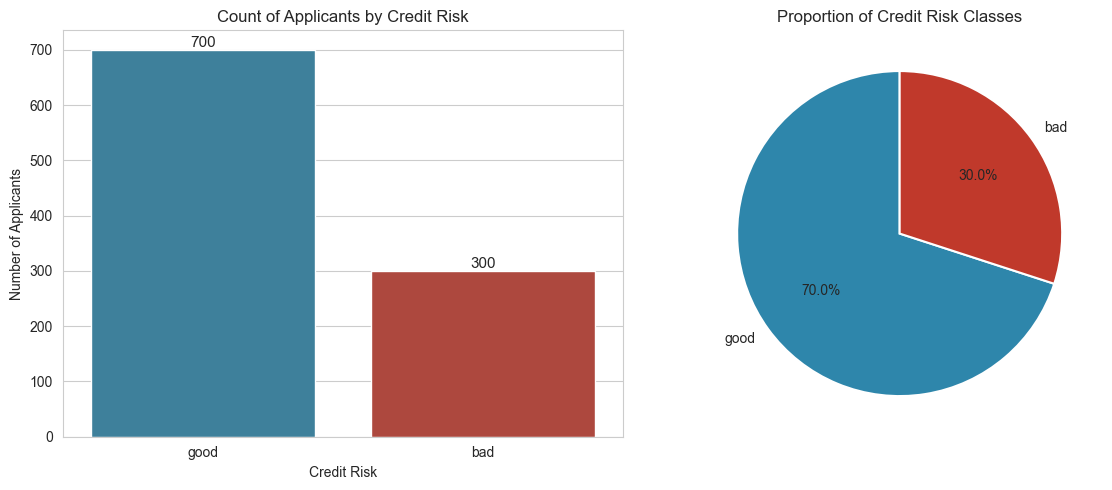

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="credit_risk", order=["good", "bad"],
              hue="credit_risk", palette={"good": "#2E86AB", "bad": "#C0392B"},
              legend=False, ax=axes[0])
axes[0].set_title("Count of Applicants by Credit Risk")
axes[0].set_xlabel("Credit Risk")
axes[0].set_ylabel("Number of Applicants")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontsize=11)

axes[1].pie(target_counts, labels=target_counts.index, autopct="%1.1f%%",
            colors=["#2E86AB", "#C0392B"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Proportion of Credit Risk Classes")

plt.tight_layout()
plt.show()

**Observation:** Of the 1,000 applicants, 700 (70%) are classified as **good** credit risk and 300 (30%) as **bad** credit risk. This represents a moderate class imbalance (roughly 2.3:1). It is not severe enough to require resampling techniques (such as SMOTE) for a first modeling pass, but it is large enough that **accuracy alone would be a misleading metric** &mdash; a trivial model that always predicts "good" would already achieve 70% accuracy without learning anything useful. This motivates the use of additional metrics such as precision, recall, F1-score, and the ROC-AUC during model evaluation, and reinforces the relevance of the dataset's own asymmetric cost matrix (misclassifying bad as good is five times costlier than the reverse).

## 6. Univariate Analysis &ndash; Numerical Features

There are 7 numerical features in this dataset: `duration_months`, `credit_amount`, `installment_rate_pct`, `present_residence_since`, `age_years`, `existing_credits_count`, and `num_dependents`. We examine each feature's distribution using histograms (to assess shape, skewness, and modality) and boxplots (to assess spread and visually flag potential outliers).

In [10]:
numerical_cols = [
    "duration_months", "credit_amount", "installment_rate_pct",
    "present_residence_since", "age_years", "existing_credits_count", "num_dependents",
]

# Skewness and kurtosis quantify distribution shape numerically, complementing the visual plots below
shape_stats = pd.DataFrame({
    "mean": df[numerical_cols].mean(),
    "median": df[numerical_cols].median(),
    "std": df[numerical_cols].std(),
    "skewness": df[numerical_cols].skew(),
    "kurtosis": df[numerical_cols].kurtosis(),
}).round(2)
shape_stats

,mean,median,std,skewness,kurtosis
duration_months,20.90,18.0,12.06,1.09,0.92
credit_amount,3271.26,2319.5,2822.74,1.95,4.29
installment_rate_pct,2.97,3.0,1.12,-0.53,-1.21
present_residence_since,2.84,3.0,1.10,-0.27,-1.38
age_years,35.55,33.0,11.38,1.02,0.60
existing_credits_count,1.41,1.0,0.58,1.27,1.60
num_dependents,1.16,1.0,0.36,1.91,1.65


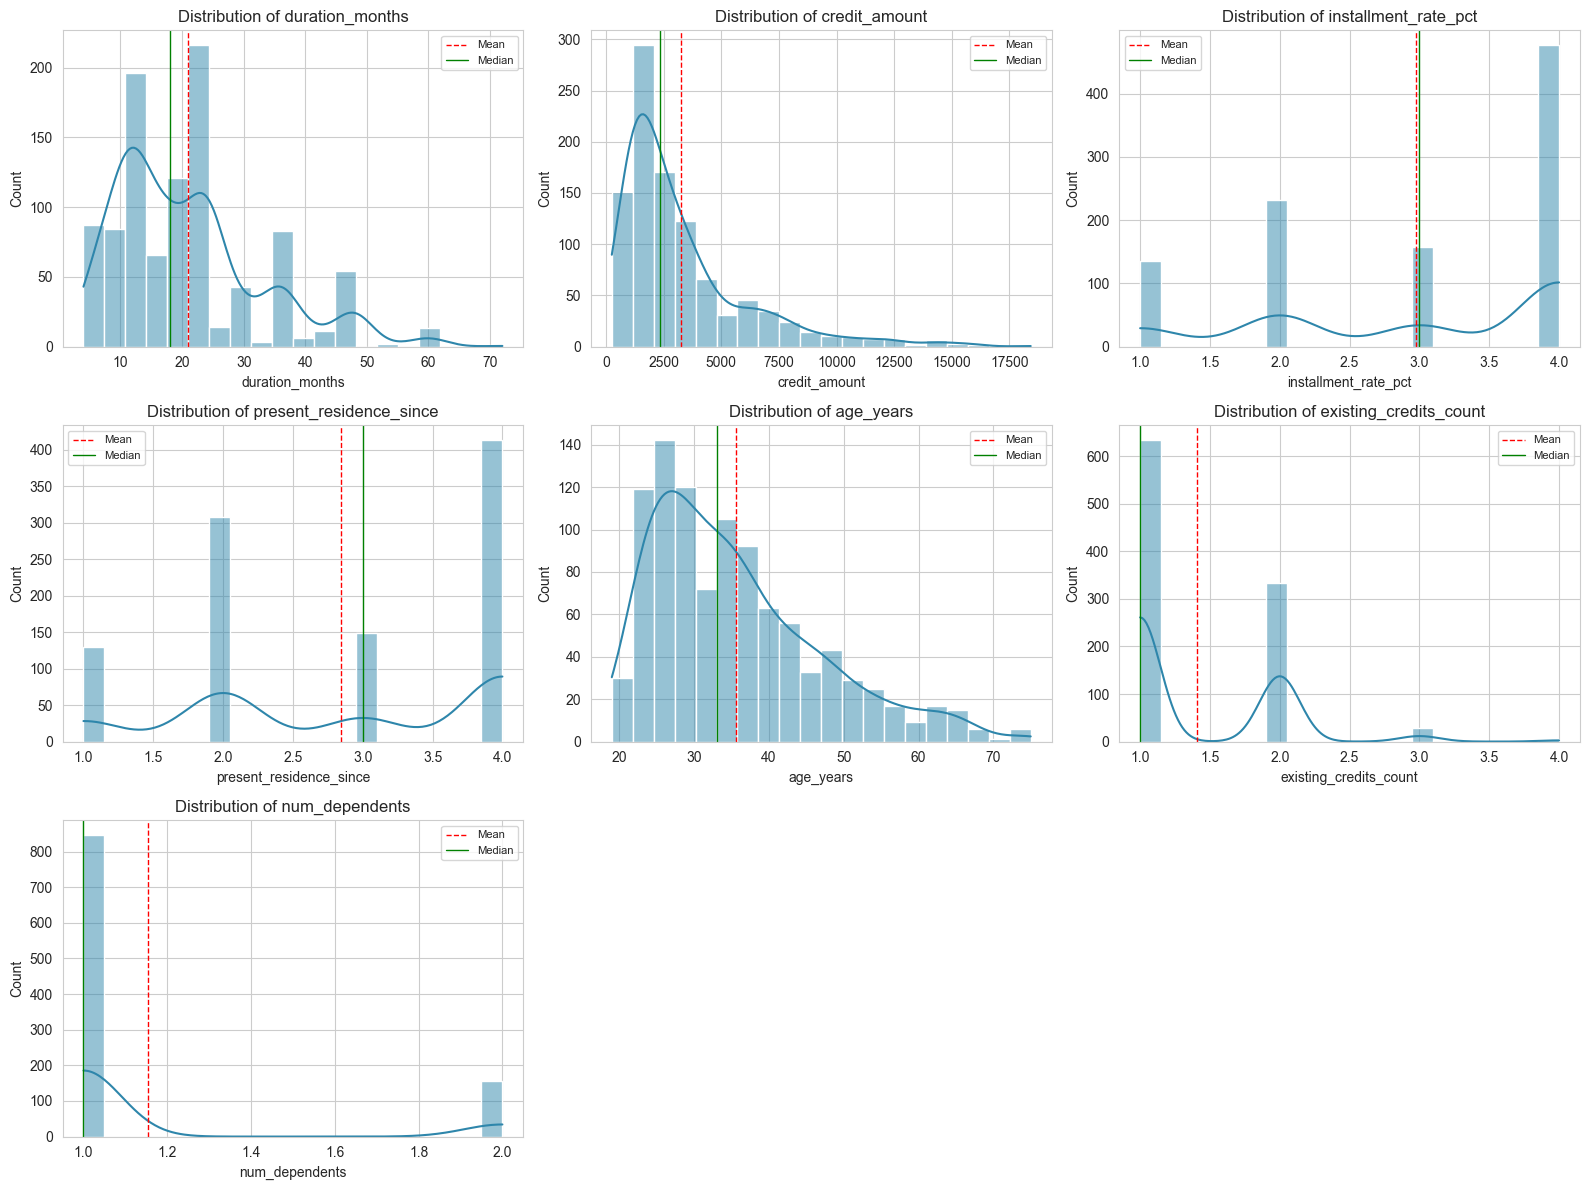

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2E86AB", bins=20)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1, label="Mean")
    axes[i].axvline(df[col].median(), color="green", linestyle="-", linewidth=1, label="Median")
    axes[i].legend(fontsize=8)

# Remove unused subplot axes (7 features in a 3x3 grid leaves 2 empty)
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

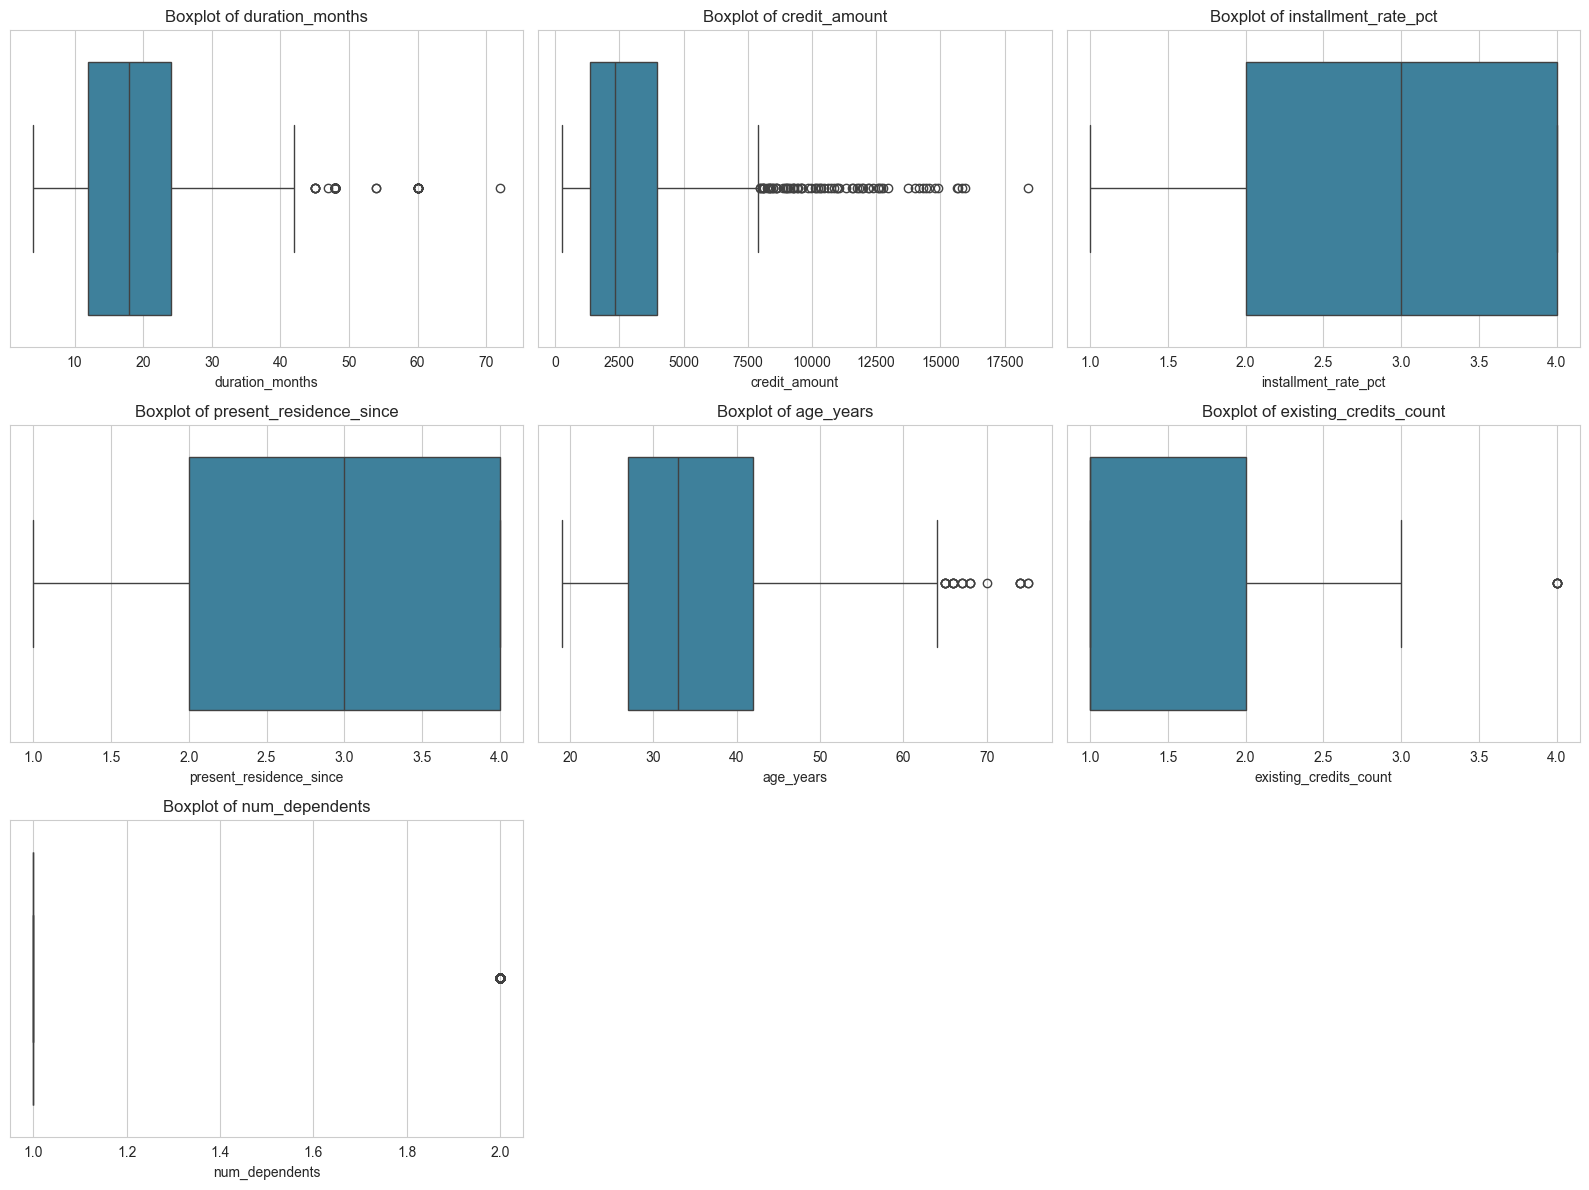

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="#2E86AB")
    axes[i].set_title(f"Boxplot of {col}")

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations on numerical features:**

- **`duration_months`** and **`credit_amount`** are both **right-skewed** (skewness of approximately 1.1 and 1.9 respectively), meaning most loans are of shorter duration and smaller amount, with a long tail of larger, longer-term loans. This is typical of financial amount data and suggests a log-transformation could be considered if linearity assumptions are violated during modeling.
- **`age_years`** is also right-skewed, reflecting a younger applicant base with fewer older applicants.
- **`installment_rate_pct`**, **`present_residence_since`**, **`existing_credits_count`**, and **`num_dependents`** are coarse, low-cardinality numerical variables (effectively ordinal scales from 1&ndash;4), so their histograms appear blocky rather than continuous. They behave more like ordered categorical variables than continuous measurements.
- The boxplots confirm that **`credit_amount`** and **`duration_months`** contain a number of points beyond the upper whisker, consistent with their right-skewed distributions. These will be examined formally in the dedicated Outlier Detection section (Section 11) rather than removed prematurely here.

## 7. Univariate Analysis &ndash; Categorical Features

There are 13 categorical predictor features. For each, we plot the frequency of every category to understand how applicants are distributed across the levels of that variable. This is important both for general understanding and for flagging any categories that are so rare they may need to be grouped before modeling (sparse categories can produce unstable coefficient estimates in Logistic Regression).

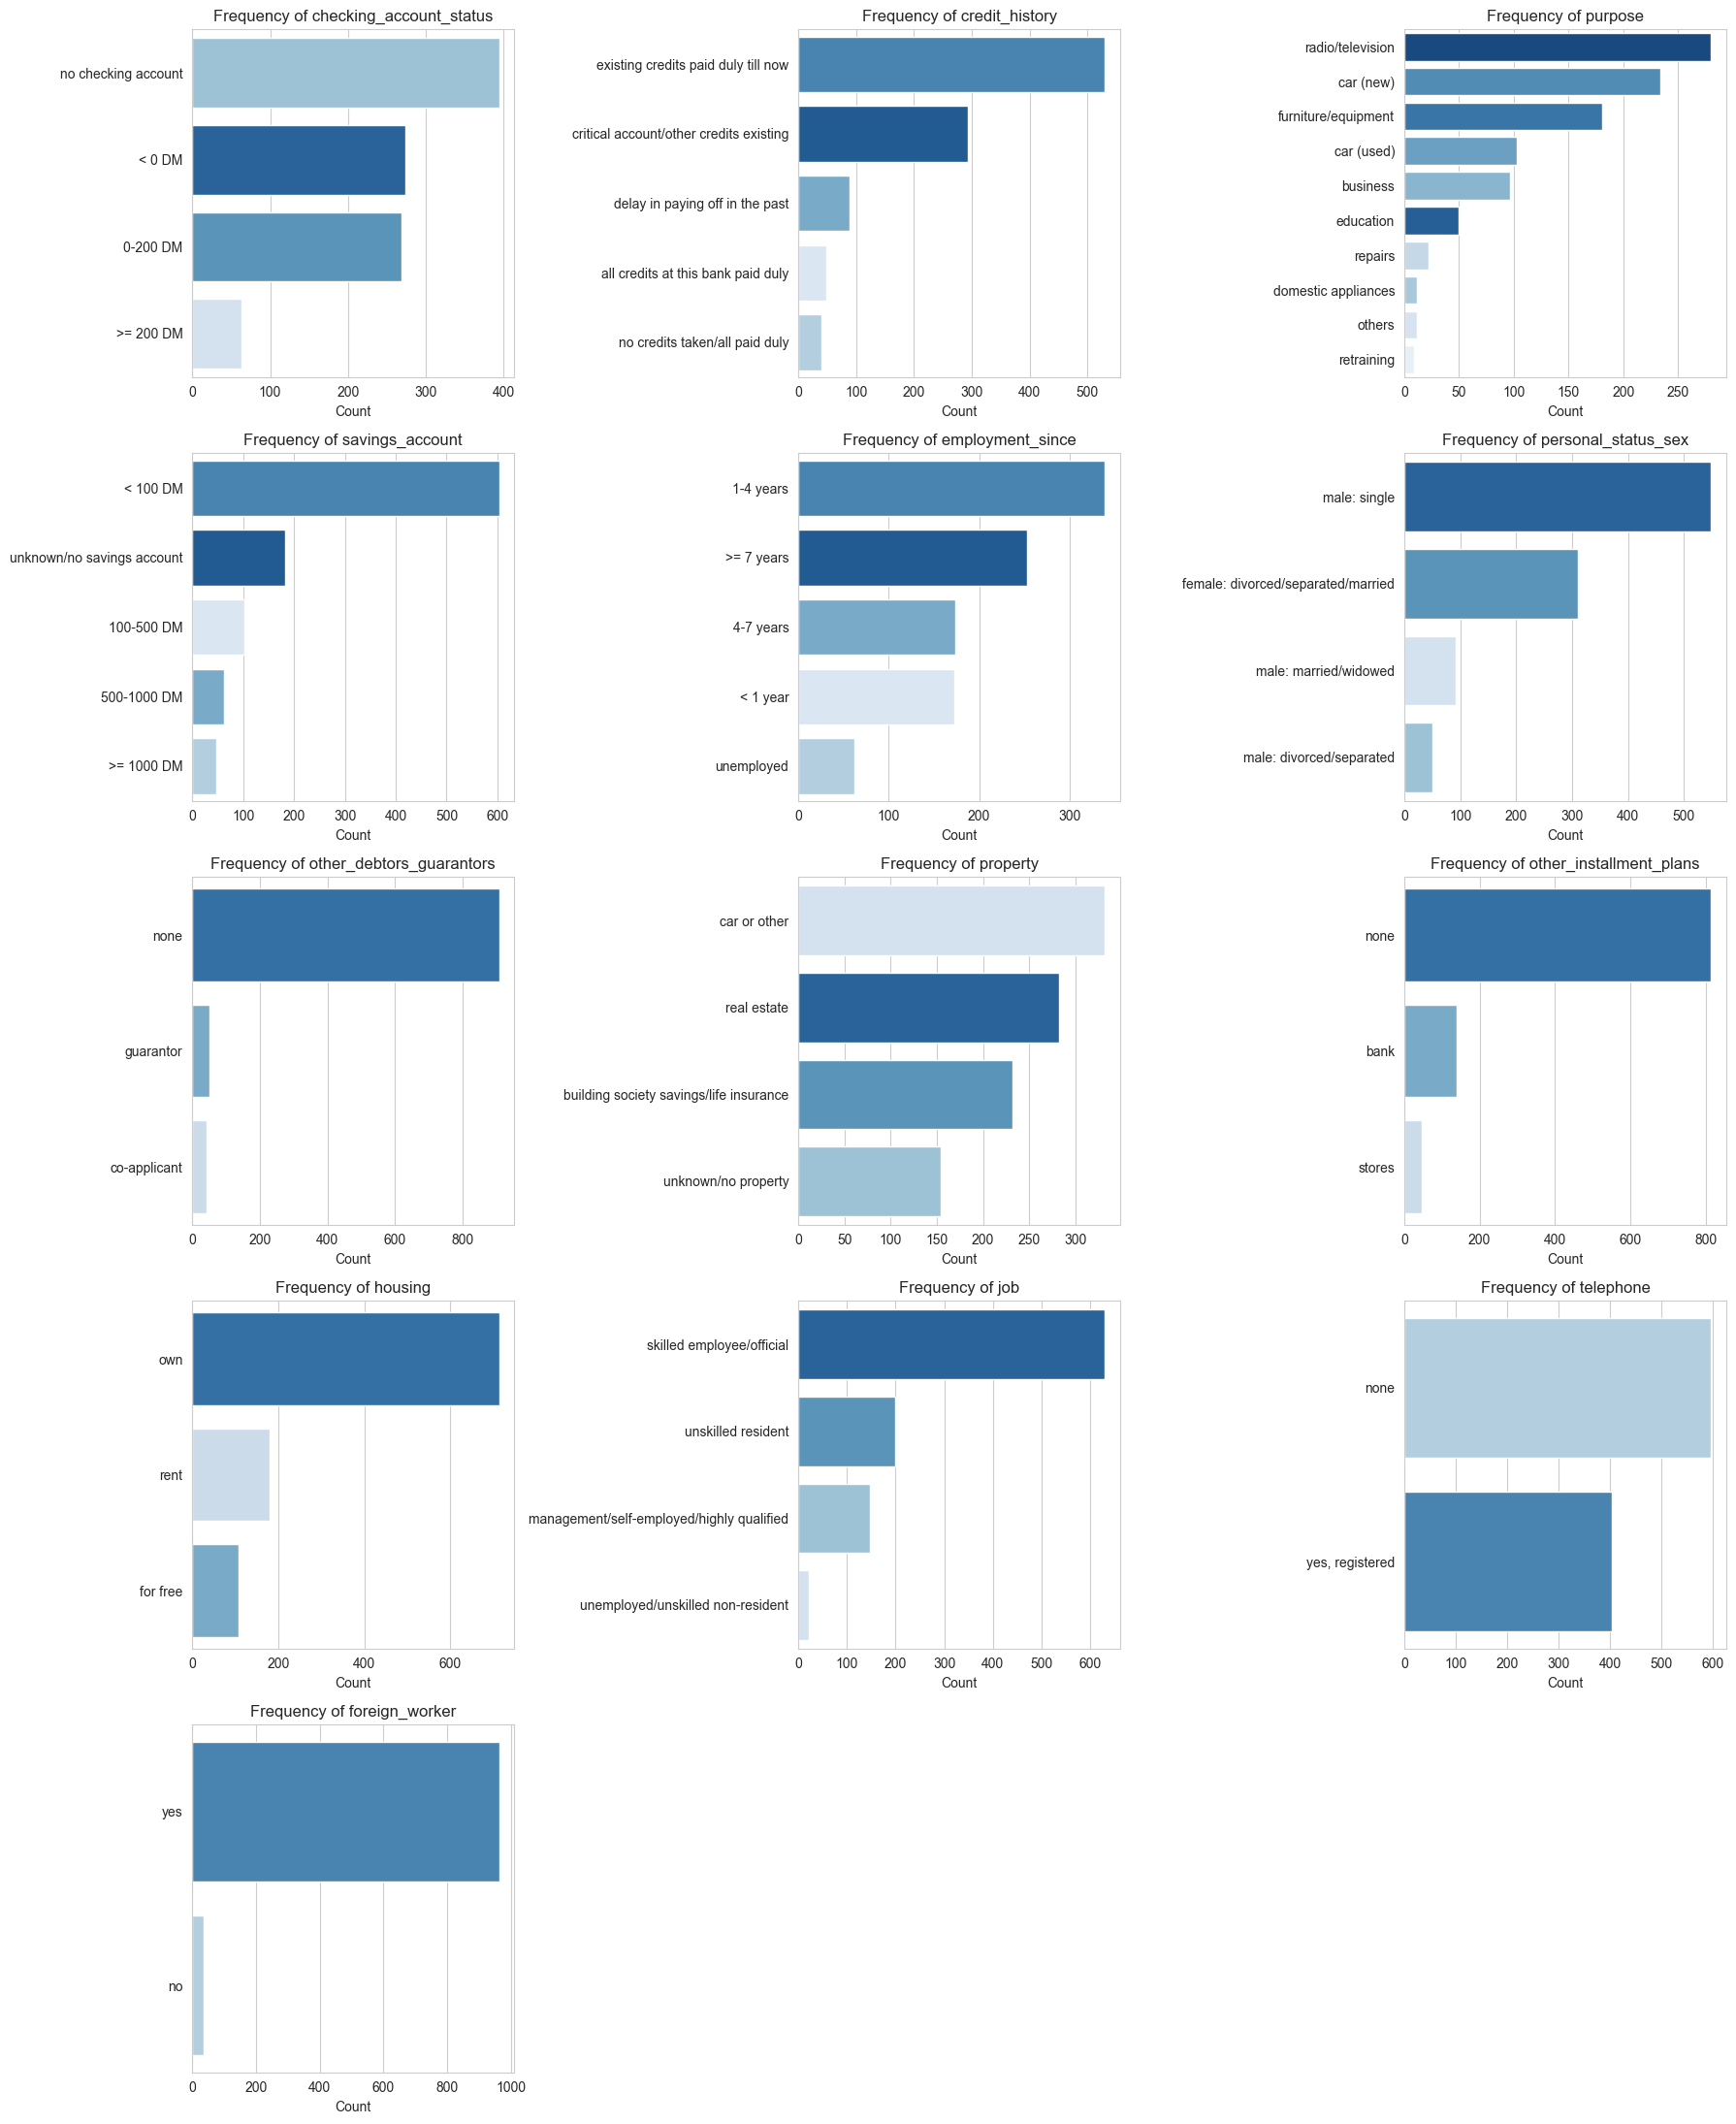

In [13]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, hue=col, palette="Blues_r",
                  legend=False, ax=axes[i])
    axes[i].set_title(f"Frequency of {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [14]:
# Identify any sparse categories (less than 5% of the dataset) that may warrant grouping later
print("Categories representing less than 5% of applicants (n < 50):\
")
for col in categorical_cols:
    counts = df[col].value_counts()
    sparse = counts[counts < 50]
    if len(sparse) > 0:
        print(f"{col}:")
        print(sparse.to_string())
        print()

Categories representing less than 5% of applicants (n < 50):
credit_history:
credit_history
all credits at this bank paid duly    49
no credits taken/all paid duly        40

purpose:
purpose
repairs                22
domestic appliances    12
others                 12
retraining              9

savings_account:
savings_account
>= 1000 DM    48

other_debtors_guarantors:
other_debtors_guarantors
co-applicant    41

other_installment_plans:
other_installment_plans
stores    47

job:
job
unemployed/unskilled non-resident    22

foreign_worker:
foreign_worker
no    37



**Observations on categorical features:**

- **`purpose`** is dominated by a few categories (radio/television, car (new), furniture/equipment), while categories like `education`, `retraining`, and `domestic appliances` are comparatively rare.
- **`personal_status_sex`** shows that single males form the largest group, and the dataset does not separately distinguish single females from divorced/separated/married females (combined into one category per the original survey design) — a limitation of the source data rather than a processing artifact.
- **`foreign_worker`** is extremely imbalanced: 963 of 1,000 applicants are foreign workers under this dataset's definition, with only 37 in the non-foreign-worker category. With such a small subgroup, any estimate of risk for that category should be treated cautiously despite appearing statistically significant (examined further in Section 12).
- Several categorical variables (e.g., `other_debtors_guarantors`, `other_installment_plans`) are dominated by a single "none" category, meaning most predictive signal from these features comes from a minority of applicants.
- Categories with very few observations are flagged above; the dataset's overall sample size (1,000) is small enough that some categories will inevitably be sparse. These will be kept as-is for the EDA stage, but may be candidates for consolidation prior to model fitting to avoid unstable coefficient estimates driven by very few observations.

## 8. Bivariate Analysis &ndash; Numerical Features vs. Target

We now examine how each numerical feature differs between the **good** and **bad** credit risk groups. Boxplots grouped by `credit_risk` allow visual comparison of central tendency and spread between the two classes, which gives an early, informal indication of which features might be predictive &mdash; to be confirmed formally with hypothesis tests in Section 12.

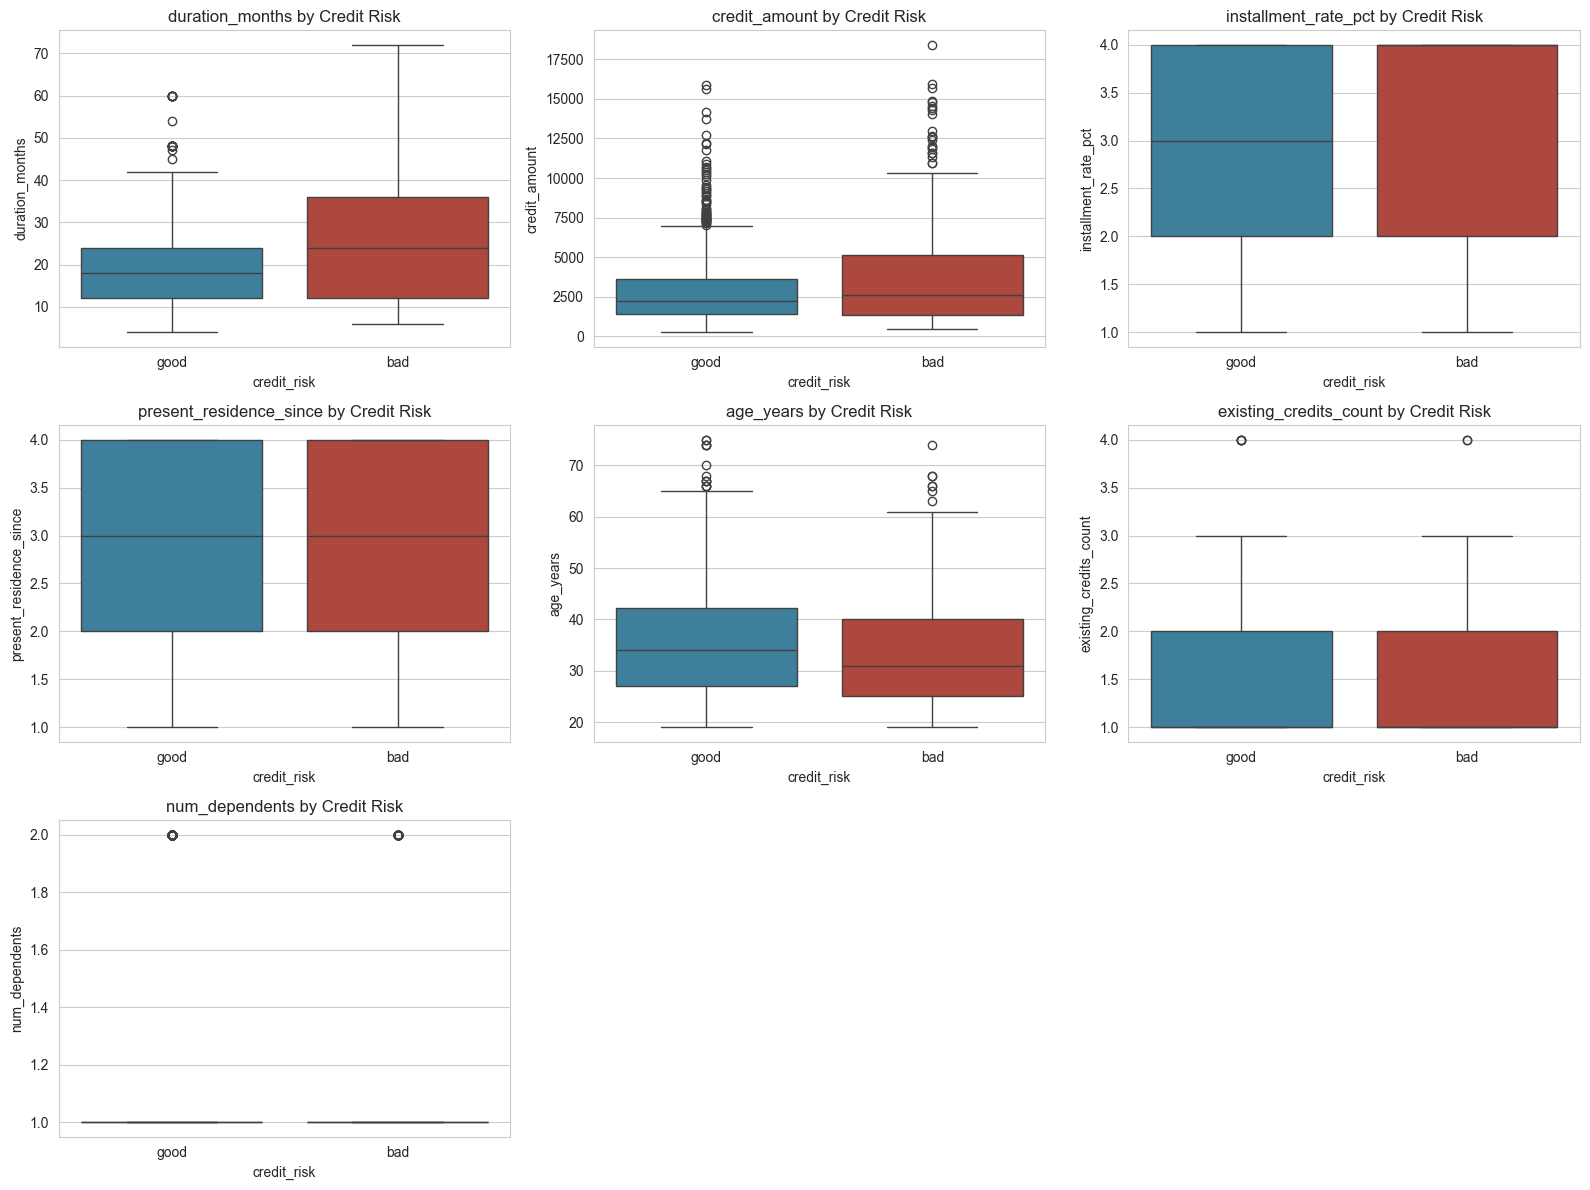

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x="credit_risk", y=col, order=["good", "bad"],
                hue="credit_risk", palette={"good": "#2E86AB", "bad": "#C0392B"},
                legend=False, ax=axes[i])
    axes[i].set_title(f"{col} by Credit Risk")

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
# Group-wise mean and median for each numerical feature, by credit risk class
df.groupby("credit_risk")[numerical_cols].agg(["mean", "median"]).round(2).T

credit_risk                         bad     good
duration_months         mean      24.86    19.21
                        median    24.00    18.00
credit_amount           mean    3938.13  2985.46
                        median  2574.50  2244.00
installment_rate_pct    mean       3.10     2.92
                        median     4.00     3.00
present_residence_since mean       2.85     2.84
                        median     3.00     3.00
age_years               mean      33.96    36.22
                        median    31.00    34.00
existing_credits_count  mean       1.37     1.42
                        median     1.00     1.00
num_dependents          mean       1.15     1.16
                        median     1.00     1.00

**Observations on numerical features vs. target:** *(see the group-wise summary table above for exact figures)*

- **`duration_months`**: Applicants classified as bad credit risk tend to have **longer** loan durations on average than good credit risk applicants. Longer repayment terms are generally associated with greater repayment risk, which aligns with domain intuition.
- **`credit_amount`**: Bad credit risk applicants tend to request **larger** credit amounts on average. Combined with the longer duration finding, this suggests that larger, longer-term loans carry more risk than smaller, shorter-term ones.
- **`age_years`**: Good credit risk applicants tend to be **slightly older** on average than bad credit risk applicants, consistent with the common credit-scoring heuristic that older applicants (often with more stable income and credit history) are perceived as lower risk.
- **`installment_rate_pct`**, **`present_residence_since`**, **`existing_credits_count`**, and **`num_dependents`** show comparatively **small differences** between the two groups, suggesting these features carry weaker univariate discriminative power. This will be tested formally in Section 12.

## 9. Bivariate Analysis &ndash; Categorical Features vs. Target

For categorical predictors, the relevant comparison is the **proportion of bad credit risk applicants within each category**, rather than raw counts (since category sizes differ substantially). We compute, for every category of every categorical feature, the percentage of applicants classified as bad credit risk, and visualize this as 100%-stacked bar charts. A category whose bad-risk proportion deviates strongly from the dataset's overall 30% baseline is a signal that the feature carries information about credit risk.

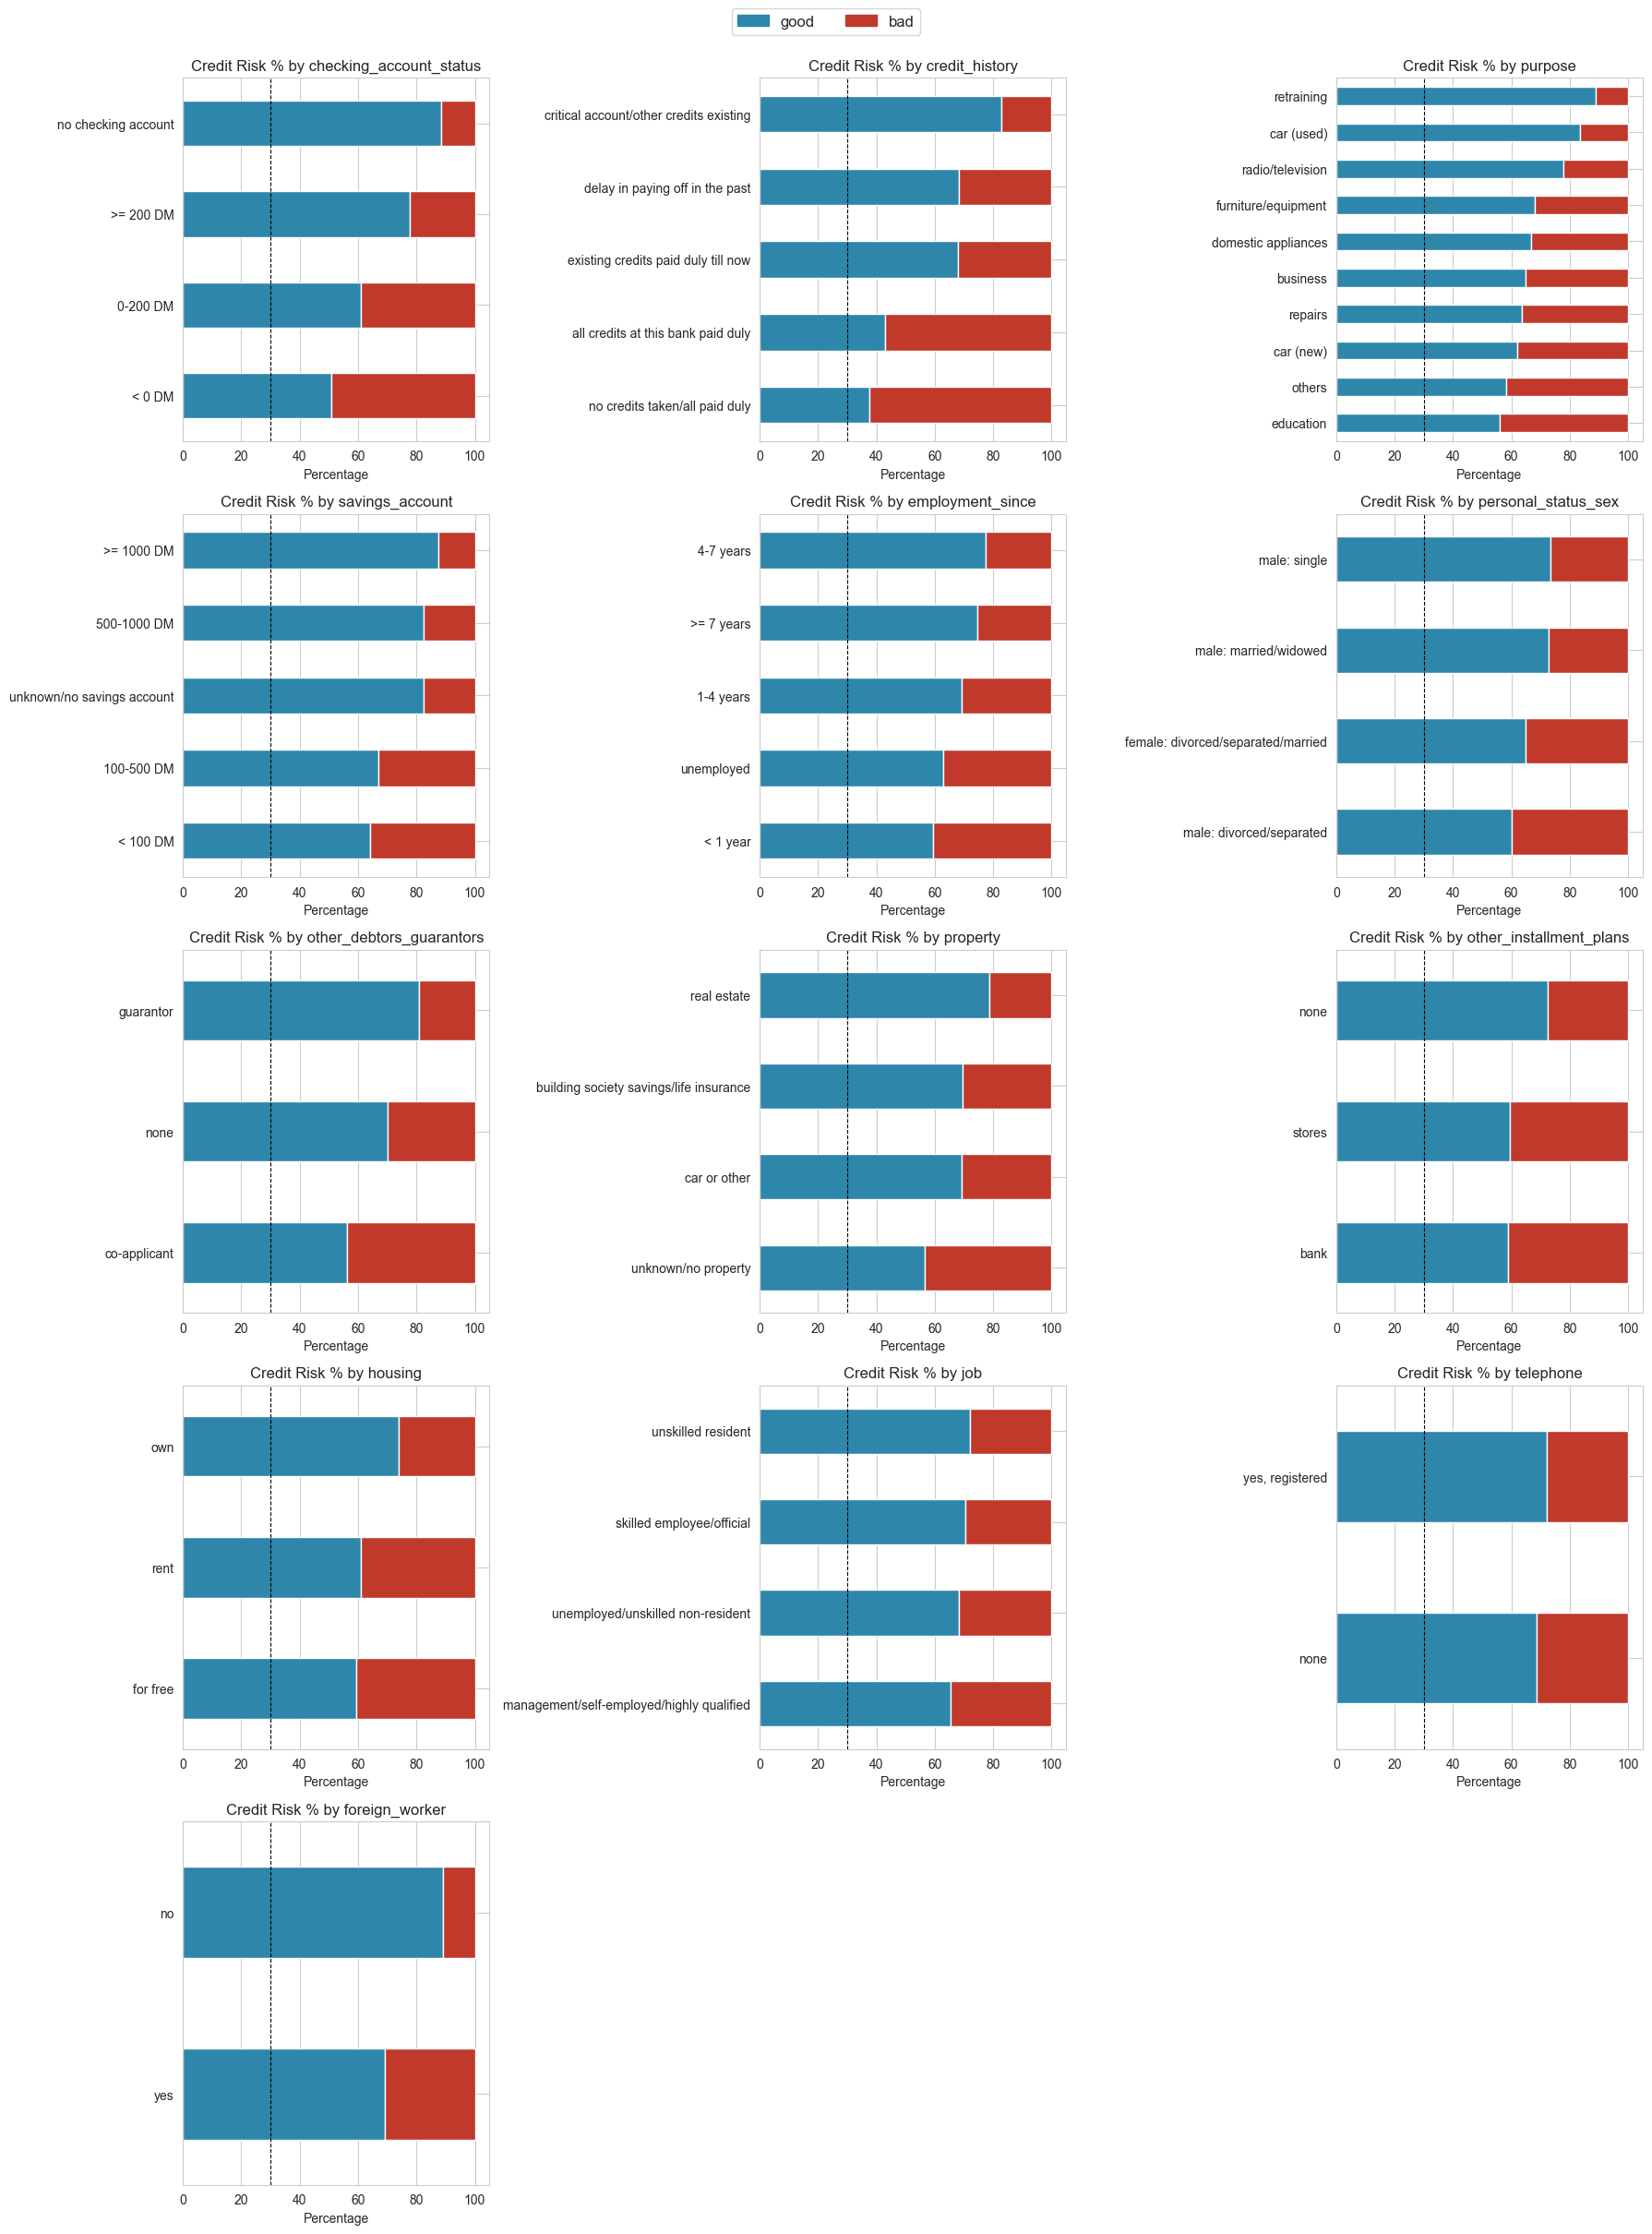

In [17]:
fig, axes = plt.subplots(5, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df["credit_risk"], normalize="index") * 100
    ct = ct.sort_values(by="bad", ascending=False)
    ct[["good", "bad"]].plot(kind="barh", stacked=True, ax=axes[i],
                               color=["#2E86AB", "#C0392B"], legend=False)
    axes[i].set_title(f"Credit Risk % by {col}")
    axes[i].set_xlabel("Percentage")
    axes[i].set_ylabel("")
    axes[i].axvline(30, color="black", linestyle="--", linewidth=0.8)

handles = [plt.Rectangle((0, 0), 1, 1, color="#2E86AB"), plt.Rectangle((0, 0), 1, 1, color="#C0392B")]
fig.legend(handles, ["good", "bad"], loc="upper center", ncol=2, fontsize=12, bbox_to_anchor=(0.5, 1.01))

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

**Observations on categorical features vs. target:**

- **`checking_account_status`** shows a strong relationship with credit risk: applicants with **no checking account** have a notably *lower* bad-risk rate than those with a checking balance below 0 DM, who show a markedly *higher* bad-risk rate. This is somewhat counter-intuitive at first glance, but is a well-documented pattern in this dataset — "no checking account" can reflect applicants who simply do not use that type of account (e.g., due to alternative banking arrangements) rather than financial distress.
- **`credit_history`** is informative: applicants with a **critical account / other credits existing** history actually show a *lower* bad-risk rate than those with **existing credits paid back duly till now**, which initially appears counter-intuitive but reflects how this dataset's bank approved loans — applicants with a track record (even a checkered one) at other institutions were evaluated differently than first-time or thin-file borrowers.
- **`savings_account`** shows the expected direction: applicants with **little or no savings** have a higher bad-risk rate than those with substantial savings.
- **`purpose`**, **`property`**, and **`housing`** show moderate variation in bad-risk rate across categories, suggesting some, but not overwhelming, predictive value individually.
- **`foreign_worker`** shows a notably lower bad-risk rate among non-foreign workers (about 11%) versus foreign workers (about 31%). This is a large apparent gap, but it rests on only 37 non-foreign-worker applicants, so the estimate for that group carries wide uncertainty. **`telephone`**, by contrast, shows minimal difference in bad-risk rate across its categories and is unlikely to contribute much to the final model.

These patterns are explored further with **formal hypothesis testing** in Section 12, since visual differences in stacked bar charts can be influenced by small category sizes and should not be interpreted as statistically significant without a formal test.

## 10. Correlation Analysis

We examine pairwise **Pearson correlation coefficients** among the numerical features. This serves two purposes: (1) understanding which numerical predictors move together, and (2) providing an early indication of potential multicollinearity, which will be assessed formally using the Variance Inflation Factor in Section 13.

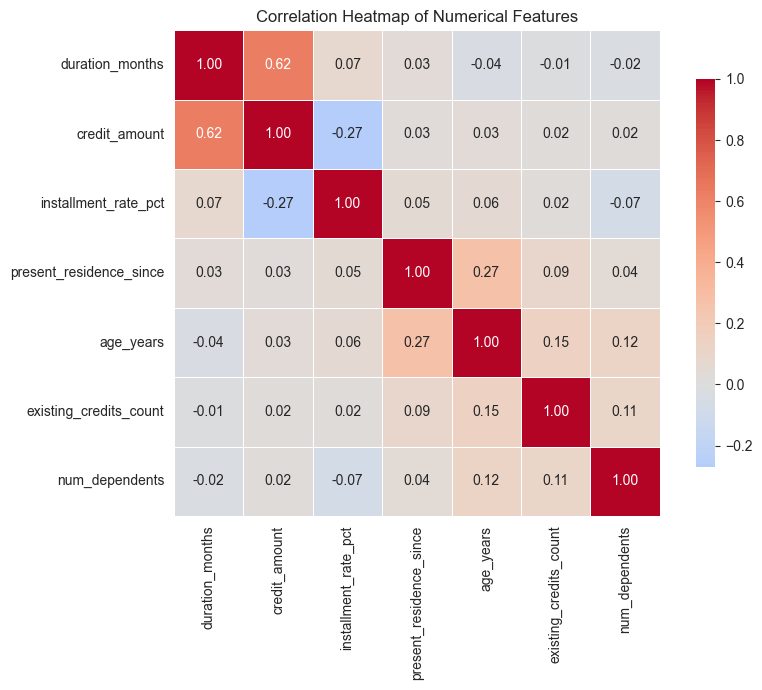

In [18]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**Observation:** The strongest correlation among numerical predictors is between **`duration_months`** and **`credit_amount`** (moderate positive correlation), which makes intuitive sense: larger loans are typically repaid over longer terms. This correlation is **not strong enough to indicate severe multicollinearity** on its own (a common rule of thumb flags concern above |r| &gt; 0.7&ndash;0.8), but it is formally re-examined using VIF in Section 13, since pairwise correlation alone can miss multicollinearity that involves three or more variables jointly. All other pairwise correlations among numerical features are weak, suggesting limited linear redundancy among the remaining numerical predictors.

## 11. Outlier Detection (IQR Method)

The boxplots in Section 6 visually suggested the presence of outliers in some numerical features. We now quantify this formally using the **Interquartile Range (IQR) method**: any value below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$ is flagged as a statistical outlier. This is a standard, distribution-free rule of thumb that does not assume normality, which is appropriate given the skewness observed earlier.

In [19]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        rows.append({
            "feature": col,
            "lower_bound": round(lower_bound, 2),
            "upper_bound": round(upper_bound, 2),
            "num_outliers": len(outliers),
            "pct_outliers": round(len(outliers) / len(data) * 100, 2),
        })
    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(df, numerical_cols)
outlier_summary

,feature,lower_bound,upper_bound,num_outliers,pct_outliers
0,duration_months,-6.00,42.00,70,7.0
1,credit_amount,-2544.62,7882.38,72,7.2
2,installment_rate_pct,-1.00,7.00,0,0.0
3,present_residence_since,-1.00,7.00,0,0.0
4,age_years,4.50,64.50,23,2.3
5,existing_credits_count,-0.50,3.50,6,0.6
6,num_dependents,1.00,1.00,155,15.5


**Observation and decision on outliers:** `credit_amount`, `duration_months`, and `age_years` contain the largest share of IQR-flagged outliers, consistent with their right-skewed distributions identified in Section 6. Importantly, these are **not data entry errors** &mdash; they represent genuine, plausible applicants (e.g., a large loan amount, an older applicant, or a long repayment duration are all realistic in a credit context). 

For this reason, **no outliers are removed at the EDA stage.** Deleting them would discard legitimate information about exactly the kind of higher-risk, higher-value applicants the model needs to learn from. This decision is deferred to, and will be revisited in, the modeling notebook, where options such as **log-transformation** (to reduce the influence of extreme values while retaining them) or **robust scaling** can be evaluated on their effect on model performance, rather than discarding data based on a generic statistical rule alone.

## 12. Statistical Significance Testing

Visual patterns from Sections 8 and 9 are suggestive but not conclusive. We now apply formal hypothesis tests, at a significance level of **&alpha; = 0.05**, to determine which features have a statistically significant association with `credit_risk`.

- **Categorical features vs. target:** We use the **Chi-Square Test of Independence**, which is the appropriate test for association between two categorical variables. The null hypothesis is that the feature and credit risk are independent.
- **Numerical features vs. target:** We use the **Mann-Whitney U test** (a non-parametric test) rather than the independent-samples t-test. This choice is deliberate: several numerical features (e.g., `credit_amount`, `duration_months`) were shown in Section 6 to be notably skewed, violating the normality assumption that the t-test relies on. The Mann-Whitney U test compares the distributions of the two groups (good vs. bad) without assuming normality, making it the more statistically appropriate choice here.

In [20]:
# Chi-Square Test of Independence for each categorical feature against credit_risk
chi2_results = []
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df["credit_risk"])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    chi2_results.append({
        "feature": col,
        "chi2_statistic": round(chi2, 3),
        "degrees_of_freedom": dof,
        "p_value": round(p_value, 4),
        "significant_at_0.05": p_value < 0.05,
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("p_value").reset_index(drop=True)
chi2_df

,feature,chi2_statistic,degrees_of_freedom,p_value,significant_at_0.05
0,checking_account_status,123.721,3,0.0000,True
1,credit_history,61.691,4,0.0000,True
2,savings_account,36.099,4,0.0000,True
3,property,23.720,3,0.0000,True
4,purpose,33.356,9,0.0001,True
5,housing,18.200,2,0.0001,True
6,employment_since,18.368,4,0.0010,True
7,other_installment_plans,12.839,2,0.0016,True
8,foreign_worker,5.822,1,0.0158,True
9,personal_status_sex,9.605,3,0.0222,True


In [21]:
# Mann-Whitney U test for each numerical feature, comparing the 'good' and 'bad' groups
mwu_results = []
for col in numerical_cols:
    good_vals = df.loc[df["credit_risk"] == "good", col]
    bad_vals = df.loc[df["credit_risk"] == "bad", col]
    u_stat, p_value = stats.mannwhitneyu(good_vals, bad_vals, alternative="two-sided")
    mwu_results.append({
        "feature": col,
        "u_statistic": round(u_stat, 1),
        "p_value": round(p_value, 4),
        "significant_at_0.05": p_value < 0.05,
    })

mwu_df = pd.DataFrame(mwu_results).sort_values("p_value").reset_index(drop=True)
mwu_df

,feature,u_statistic,p_value,significant_at_0.05
0,duration_months,77995.5,0.0000,True
1,age_years,119833.0,0.0004,True
2,credit_amount,93480.0,0.0059,True
3,installment_rate_pct,95889.5,0.0199,True
4,existing_credits_count,110272.0,0.1348,False
5,num_dependents,105250.0,0.9242,False
6,present_residence_since,104680.5,0.9358,False


**Interpretation:** The tables above rank features by p-value, from most to least statistically significant. Features with `significant_at_0.05 = True` show a statistically significant association with credit risk and are strong candidates for inclusion in the Logistic Regression model. Features that are *not* significant are not necessarily useless &mdash; they may still contribute jointly with other variables in a multivariate model &mdash; but on their own, we cannot reject the null hypothesis that they are unrelated to credit risk. This ranked evidence, combined with the visual patterns from Sections 8 and 9, forms the statistical basis for feature selection in the subsequent modeling notebook.

## 13. Multicollinearity Check (Variance Inflation Factor)

Logistic Regression coefficients become unstable and difficult to interpret when predictors are highly collinear. The **Variance Inflation Factor (VIF)** quantifies how much the variance of a coefficient is inflated due to linear correlation with other predictors. A common rule of thumb is:

- VIF &lt; 5: low multicollinearity, generally acceptable
- 5 &le; VIF &lt; 10: moderate multicollinearity, worth monitoring
- VIF &ge; 10: high multicollinearity, action (e.g., removing or combining variables) is usually warranted

We compute VIF for the numerical features here. (Categorical features will be one-hot encoded prior to modeling; a complete VIF check including those encoded dummy variables will be repeated in the modeling notebook once the full design matrix is built.)

In [22]:
vif_data = df[numerical_cols].copy()
vif_data = (vif_data - vif_data.mean()) / vif_data.std()  # standardize to stabilize VIF computation
vif_data = vif_data.assign(intercept=1.0)

vif_results = pd.DataFrame({
    "feature": numerical_cols,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(len(numerical_cols))],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_results

,feature,VIF
0,credit_amount,1.994152
1,duration_months,1.857215
2,installment_rate_pct,1.227527
3,age_years,1.121527
4,present_residence_since,1.082781
5,existing_credits_count,1.036226
6,num_dependents,1.030099


**Interpretation:** All numerical features show VIF values well below the conventional concern threshold of 5, confirming the impression from the correlation heatmap in Section 10 &mdash; the moderate correlation between `duration_months` and `credit_amount` is not severe enough to cause problematic multicollinearity. This means all seven numerical features can be safely included together in the Logistic Regression model without redundancy concerns at this stage. The categorical predictors will be re-checked for multicollinearity (via VIF on their encoded dummy variables) once the modeling notebook constructs the full design matrix.

## 14. Key Findings and Conclusion

**Data quality:** The dataset is clean &mdash; no missing values, no duplicate records, and consistent categorical labels across all 1,000 records. No imputation or deduplication was required.

**Target variable:** `credit_risk` is moderately imbalanced (70% good vs. 30% bad). This rules out plain accuracy as a sufficient evaluation metric for the upcoming model and motivates the use of precision, recall, F1-score, and ROC-AUC, in addition to consideration of the dataset's own asymmetric cost matrix.

**Numerical predictors:** `duration_months`, `credit_amount`, and `age_years` show the clearest separation between good and bad credit risk applicants, both visually (Section 8) and statistically (Section 12). Several are right-skewed, which informed the choice of the non-parametric Mann-Whitney U test over the t-test, and which may motivate a log-transformation in the modeling stage.

**Categorical predictors:** `checking_account_status`, `credit_history`, and `savings_account` emerge as the categorical features most strongly associated with credit risk, both from the proportion analysis (Section 9) and the Chi-Square tests (Section 12). Some patterns (e.g., the checking account status finding) are counter-intuitive on the surface and are noted as worth keeping in mind during model interpretation, rather than treated as anomalies to correct.

**Multicollinearity:** VIF analysis confirms that the numerical predictors are not problematically collinear, supporting their joint inclusion in the model. A repeat check is planned after encoding categorical variables.

**Outliers:** Outliers identified via the IQR method in `credit_amount`, `duration_months`, and `age_years` are retained, as they represent genuine high-value or high-risk applicants rather than data errors. Their treatment (e.g., transformation vs. retention as-is) will be evaluated empirically in the modeling stage based on its effect on model fit.

### Next Steps

This EDA provides the statistical foundation for the next stage of the project: building and evaluating a **Logistic Regression model** to predict `credit_risk`. The next notebook will cover:

1. Encoding categorical variables (one-hot/dummy encoding) and re-checking multicollinearity (VIF) on the full design matrix.
2. Feature scaling for numerical predictors.
3. Train-test splitting with stratification (to preserve the 70/30 class balance in both sets).
4. Fitting the Logistic Regression model and interpreting coefficients as **log-odds** and **odds ratios**.
5. Evaluating the model using a confusion matrix, precision, recall, F1-score, ROC curve, and AUC &mdash; with explicit reference back to the dataset's cost matrix when selecting a classification threshold.